In [2]:
import uproot
import pandas as pd
import numpy as np
import json
from scipy.optimize import curve_fit, minimize
from scipy.stats import argus
from scipy.integrate import quad
from numpy import  log, sqrt, exp, pi, e
import multiprocessing
import dill
import os
import re
from numba import njit
from source import *
from concurrent.futures import ThreadPoolExecutor, as_completed
plt.rcParams['text.usetex'] = True


In [ ]:
pd.rea

In [1]:
# Function to process each CSV file and return it as a DataFrame
def process_file(filename):
    if 'csv' in filename:
        try:
            filepath = os.path.join("inc_data", filename)
            inc = pd.read_csv(filepath)  # Read the CSV file into a DataFrame
            inc['source_file'] = filename  # Add source file info for tracking
            print(f"Processing {filename}")
            return inc
        except Exception as e:
            print(f"Failed to process {filename}: {e}")

# Main function to execute parallel processing and concatenate results
def mk_pddf():
    combined_df = pd.DataFrame()  # Initialize an empty DataFrame to accumulate results
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(process_file, filename) for filename in os.listdir("inc_data") if filename.endswith('.csv') if filename.endswith('.csv')]
        for future in as_completed(futures):
            df = future.result()
            if df is not None:
                combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    print("Combined DataFrame created.")
    return combined_df
inc = mk_pddf()


NameError: name 'pd' is not defined

In [3]:
inc.head()

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__weight__,pcm,ecm,recM,idec,XcPx,XcPy,XcPz,XcE,ach_chan,ach_first_dt_chan,charge,M,source_file
0,9,18,4192,0,0,1,1.0,2.168224,7.295832,2.459319,2.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,6.966201,9.csv
1,9,26,5098,0,0,1,1.0,2.058767,7.346984,2.485583,1.0,NaN,NaN,NaN,NaN,1.0,NaN,-1.0,7.052634,9.csv
2,9,26,6130,0,0,1,1.0,3.547123,6.283706,2.414238,1.0,NaN,NaN,NaN,NaN,1.0,NaN,-1.0,5.186799,9.csv
3,9,30,29875,0,0,1,1.0,1.649418,7.429222,2.678056,1.0,NaN,NaN,NaN,NaN,1.0,NaN,-1.0,7.243808,9.csv
4,9,30,50056,0,0,1,1.0,2.906658,7.089351,1.922855,4.0,NaN,NaN,NaN,NaN,2.0,1.0,-1.0,6.466084,9.csv


In [4]:
decay_mod_taging = ["$X_c \\to D^+ p \\pi^- $", "$X_c \\to D^0 p$", "$X_c \\to D^{*0} p$", "$X_c \\to D^{*+} p \\pi^-$"]
decay_mod_tag = {"\\Lambda \\nu_l l": [lambda x: x <= 2, "L_nu_l"], "\\Lambda \\pi" : [lambda x: x == 3, "L_pi"], "p K \\pi" : [lambda x: x == 5, "p_k_pi"]}

In [36]:
wbin = 0.01
a = 1.6
b = 2.6
bins = np.linspace(a, b, int((b-a)/wbin))


In [37]:
dat = inc[(inc.recM < 2.5) & (inc.recM > 2)]
print(dat.recM.shape[0])

940245


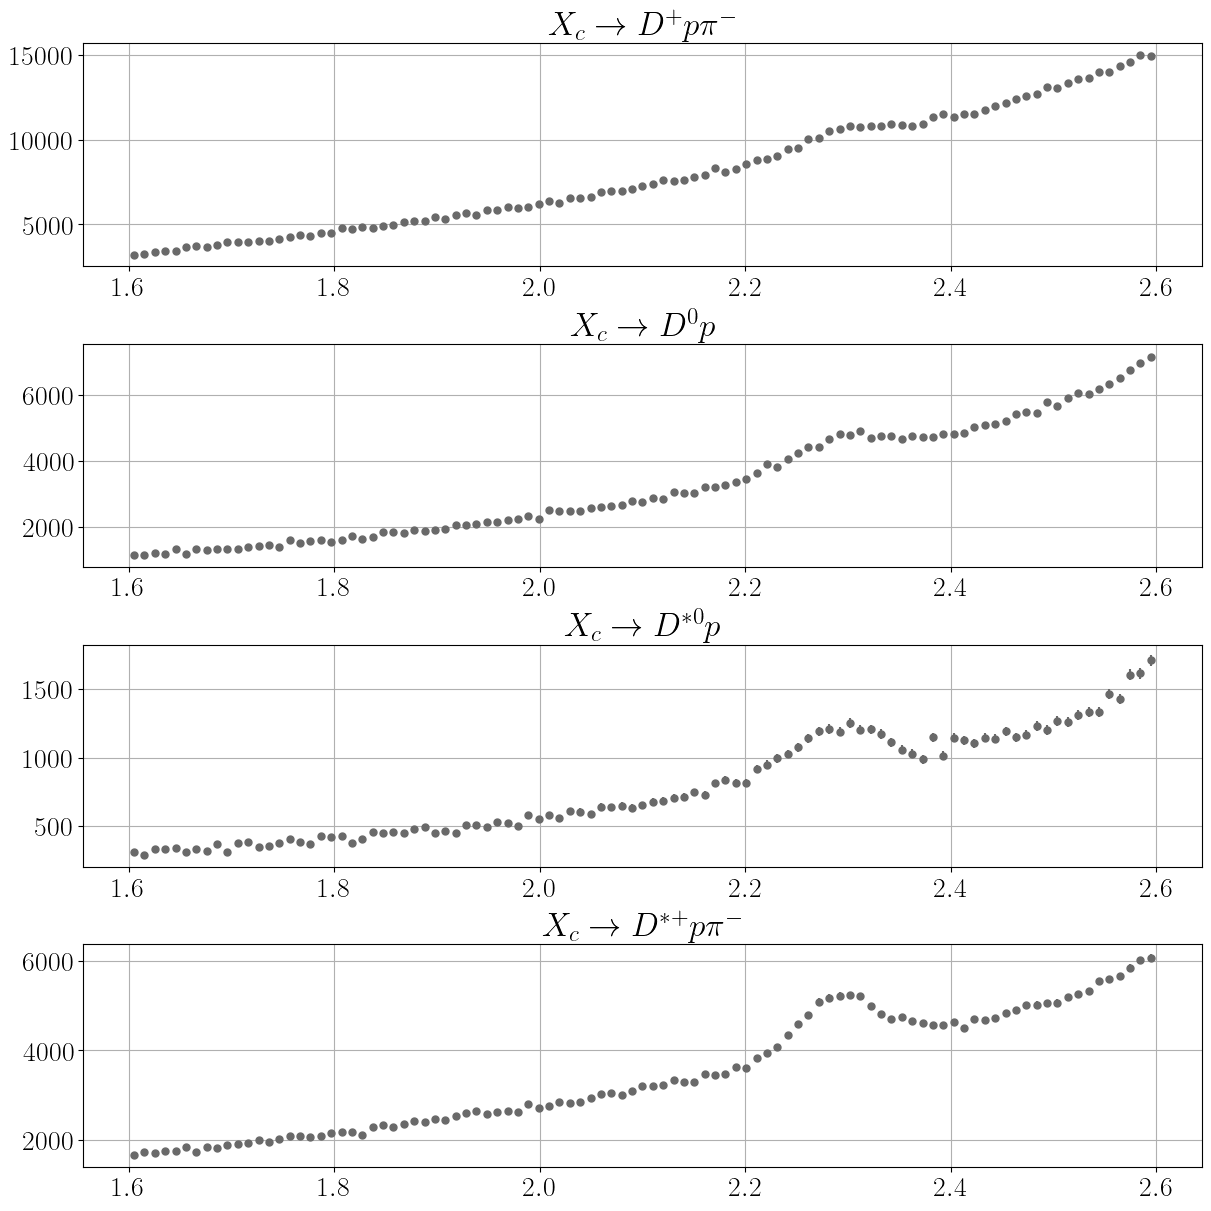

In [11]:
fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

In [12]:
dat.M

2          6.283008
5          7.947730
9          7.142636
11         8.568110
69         7.668093
             ...   
6550287    4.865446
6550289    4.854609
6550291    4.492251
6550293    4.744551
6550319    5.310695
Name: M, Length: 343771, dtype: float64

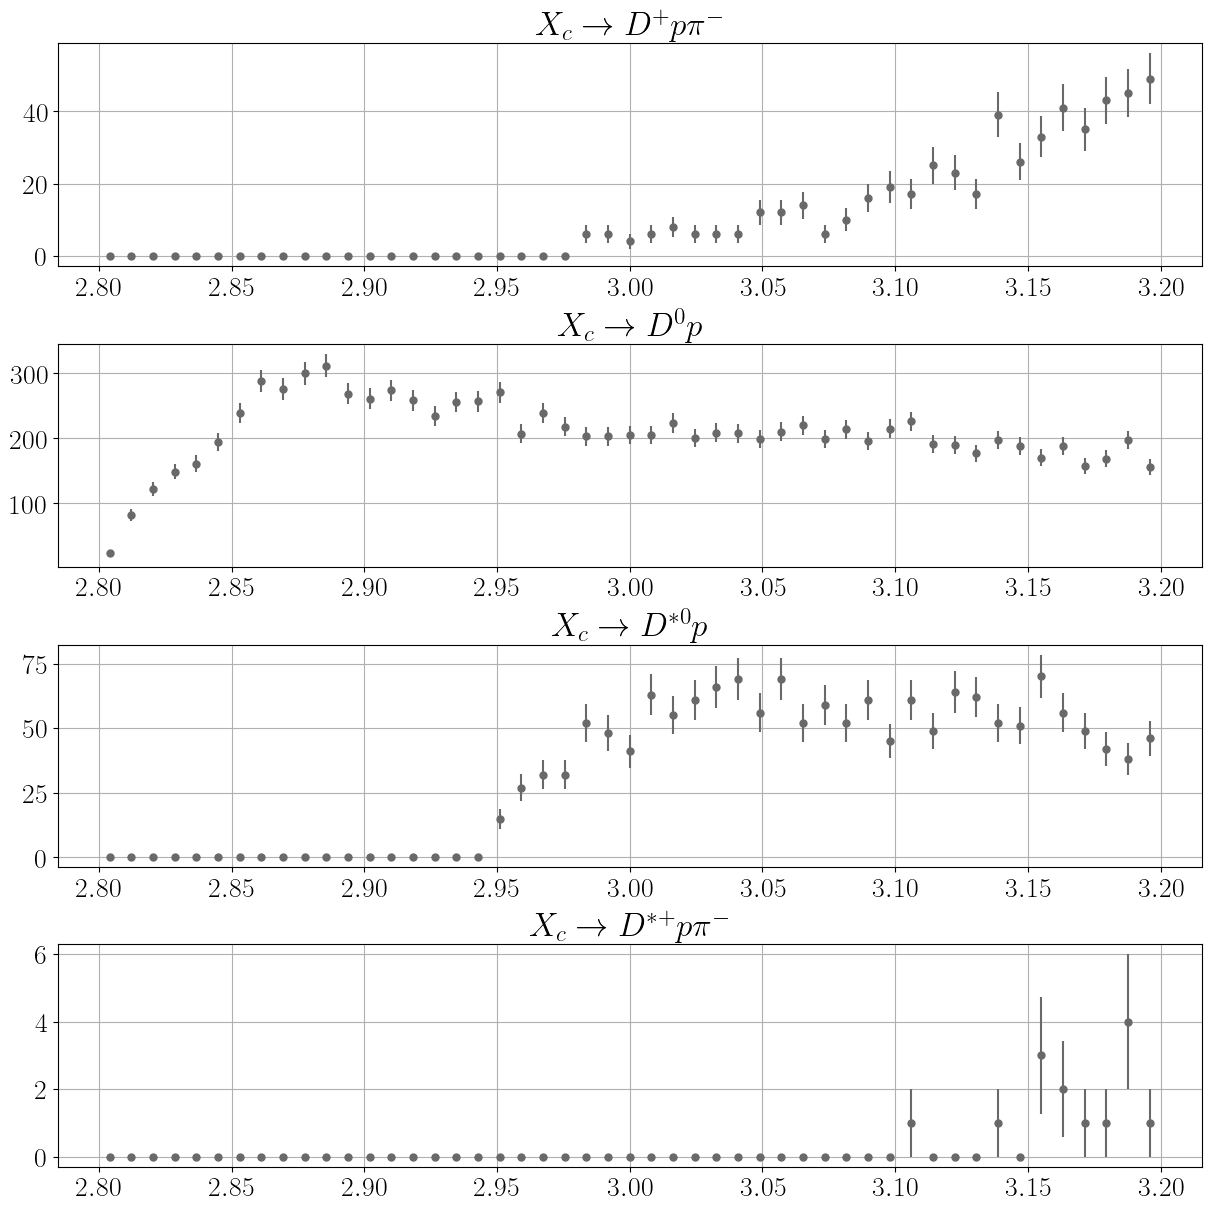

In [13]:
fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < (Lamc_m+0.1)) & (inc.recM > (Lamc_m-0.1)) & (inc.idec == i)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.M, bins=np.linspace(2.8, 3.2, 50), axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

In [5]:
f_all = [0,]*4
params_all = [0,]*4
for ind, i in enumerate([1, 2, 3, 4]):
    params_all[ind] = []
    f_all[ind] = [] 
    pattern1 = f"params_{i}.json"
    print(pattern1)
    for root, dirs, files in os.walk("output/params"):
        for filename in files:
            if re.match(pattern1, filename):
                file_path = os.path.join(root, filename)
                with open(file_path, 'r') as file:
                    print(file)
                    params_all[ind].append(json.load(file))
    print(params_all[ind])

params_1.json
<_io.TextIOWrapper name='output/params/sig/params_1.json' mode='r' encoding='UTF-8'>
<_io.TextIOWrapper name='output/params/c/params_1.json' mode='r' encoding='UTF-8'>
<_io.TextIOWrapper name='output/params/bg/params_1.json' mode='r' encoding='UTF-8'>
[{'initial_params': [2.3422488095515432, 2.296797976951529, 0.48311729560105277, 0.11199186558331883, 0.230876268913864, 0.05416849456429011, 0.028041021394805226], 'norm': 7511.000548361186}, {'initial_params': [0.0008464462266687244, 0.0017798154027277586], 'norm': 3751.999999999999}, {'initial_params': [1.6788593428792842, 2.1153031454323097, -0.022581849876698017, 0.09560346012719191], 'norm': 152555.01585299423}]
params_2.json
<_io.TextIOWrapper name='output/params/sig/params_2.json' mode='r' encoding='UTF-8'>
<_io.TextIOWrapper name='output/params/c/params_2.json' mode='r' encoding='UTF-8'>
<_io.TextIOWrapper name='output/params/bg/params_2.json' mode='r' encoding='UTF-8'>
[{'initial_params': [2.2990503994219047, 2.292

In [6]:
params_all[1]

[{'initial_params': [2.2990503994219047,
   2.2923914399936582,
   0.9777522403705146,
   0.5224734400508486,
   0.07172908803018092,
   0.03224059711073194,
   0.3138063764546542],
  'norm': 2300.0000685647883},
 {'initial_params': [3.236565747236787, 6.511184429437876], 'norm': 1803.0},
 {'initial_params': [1.5083921913072673,
   4.3577843006800565,
   -0.023573241996734835,
   -0.017496703323495014],
  'norm': 38747.00473113797}]

In [7]:
divi_g = njit(lambda x, mass1, mass2, A2, sigma1, sigma2: (A2*gaussian(x, mass1, sigma1) + (1-A2)*gaussian(x, mass2, sigma2)))
treis_g = njit(lambda x ,mass1, mass2, A1, A2, sigma1, sigma2, sigma3: (A2*gaussian(x, mass1, sigma1) + (1-A2)*gaussian(x, mass2, sigma2))*A1 + (1 - A1)*gaussian(x, Lamc_m, sigma3))
fitting_functions_s = [lambda x, *args: treis_g(x, *args)/np.sum(treis_g(x, *args)),]*4

In [8]:
def convolution_meshed(x, g, f, fargs, gargs, delta = 0.1, N = 1000, mesh = None):
    # Оптимизированная функция поиска свертки двух функций опреденных на x
    # Условие применимости 
    # f - синальная функция на X и локализованная в центре X, пик узкий (хотя он может быть не один) если нет то надо расширить S
    # g - функция фонов, определена на S - mean(X)
    # S содержит X-mean(X) так чтобы for all xi in (X-mean(X))/S, x' in x => f(xi-x) << 1
    # Кароче s = [min(x)-delta, max(x)+delta] где delta полуширина пика   
    mu = np.mean(x)
    if not(mesh is None):
        N = mesh.shape[0]
        x, s = np.meshgrid(x, mesh)
    else:
        x, s = np.meshgrid(x, np.linspace(np.min(x) - mu - delta, np.max(x) - mu + delta, N))
    return np.sum(g(s, *fargs)*f(x-s, *gargs), axis=0)/N

sq = njit(lambda x, c1, c2: c1 * np.sqrt((x - Pi_0_m) * heaviside(x, Pi_0_m))  + c2 * np.sqrt(x * heaviside(x, 0)))
def continuum_lam(i, x, c1, c2):
    return (convolution_meshed(x, sq, fitting_functions_s[i], [c1, c2], params_all[ind][0]["initial_params"], mesh=np.linspace(-1, 1, 700)))

fitting_functions_c = [(lambda x, c1, c2: continuum_lam(i, x, c1, c2)/np.sum(continuum_lam(i, x, c1, c2))) for i in list(range(4))]


In [9]:
continuum_bg = njit(lambda x, lam, mu, c0, c1: (exp_dis(x - mu, lam) + c0 + c1*eval_chebyt(1, x - Lamc_m)))
fitting_functions_bg = [lambda x, *args: continuum_bg(x, *args)/np.sum(continuum_bg(x, *args)),]*4

In [10]:
def __f (ind, x, A, *args): 
    norm = sum([params_all[ind][i]["norm"] for i in list(range(3))])
    return (fitting_functions_s[ind](x, *params_all[ind][0]["initial_params"])*params_all[ind][0]["norm"]/norm + fitting_functions_c[ind](x, *params_all[ind][1]["initial_params"])*params_all[ind][1]["norm"]/norm)*A + fitting_functions_bg[ind](x, *args)*(1-A)
def __f_ns (ind, x, A, *args): 
    norm = sum([params_all[ind][i]["norm"] for i in list(range(3))])
    return (fitting_functions_c[ind](x, *params_all[ind][1]["initial_params"])*params_all[ind][1]["norm"]/norm)*A + fitting_functions_bg[ind](x, *args)*(1-A)
def __f_ns_nc (ind, x, A, *args): 
    return fitting_functions_bg[ind](x, *args)*(1-A)


functions = [lambda x, A, *args: __f(0, x, A, *args),lambda x, A, *args:  __f(1, x, A, *args),lambda x, A, *args:  __f(2, x, A, *args),lambda x, A, *args:  __f(3, x, A, *args)]

In [11]:
wbin = 0.01
a = 2
b = 2.5
bins = np.linspace(a, b, int((b-a)/wbin))

In [12]:
def max_bin_lik(f, bin_centers, counts, args0, wbin = 1, h=1e-7, bounds=None, normm=None, method='SLSQP'):
    normalization = np.max(counts)//10
    counts = counts/normalization
    norm = np.sum(counts)
    pdf = lambda bin_centers, norm, *args: f(bin_centers,*args)/(np.sum(f(bin_centers, *args)))*norm
    args0 = [norm,] + list(args0)
    if bounds != None:
        bounds = [(0, norm*100), ] + list(bounds)
    def df(*args0):
            return -np.sum(np.log(puasson(pdf(bin_centers, *args0), counts)))
    minuit = Minuit(df, *args0)
    minuit.migrad()
    rez = minuit.values
    norm = rez[0]*normalization
    print(rez)
    return rez[1:], pdf, norm

In [13]:
initial_params_s = [[params_all[ind][2]["norm"]/sum([params_all[ind][i]["norm"] for i in list(range(3))]), *params_all[ind][2]["initial_params"]] for ind in range(4)]


<ValueView x0=354.8247958027483 x1=0.27850788297617646 x2=0.07225719733872754 x3=9.026642197109174 x4=2.0173048265674454 x5=3.449783736519296>
<ValueView x0=340.0723425952488 x1=0.5402062216122335 x2=1.3523150120175242 x3=2.5080855467364747 x4=-0.01606908858090436 x5=0.04002127123579105>
<ValueView x0=366.20564652192763 x1=0.5337270205292394 x2=0.21071672440763842 x3=-7.134849001374357 x4=240.87923146672753 x5=265.87807099400055>
<ValueView x0=380.8797042198611 x1=0.4496827072148373 x2=3.1232784843952186 x3=3.6839684602939933 x4=0.49864592608193037 x5=0.45695037492290425>


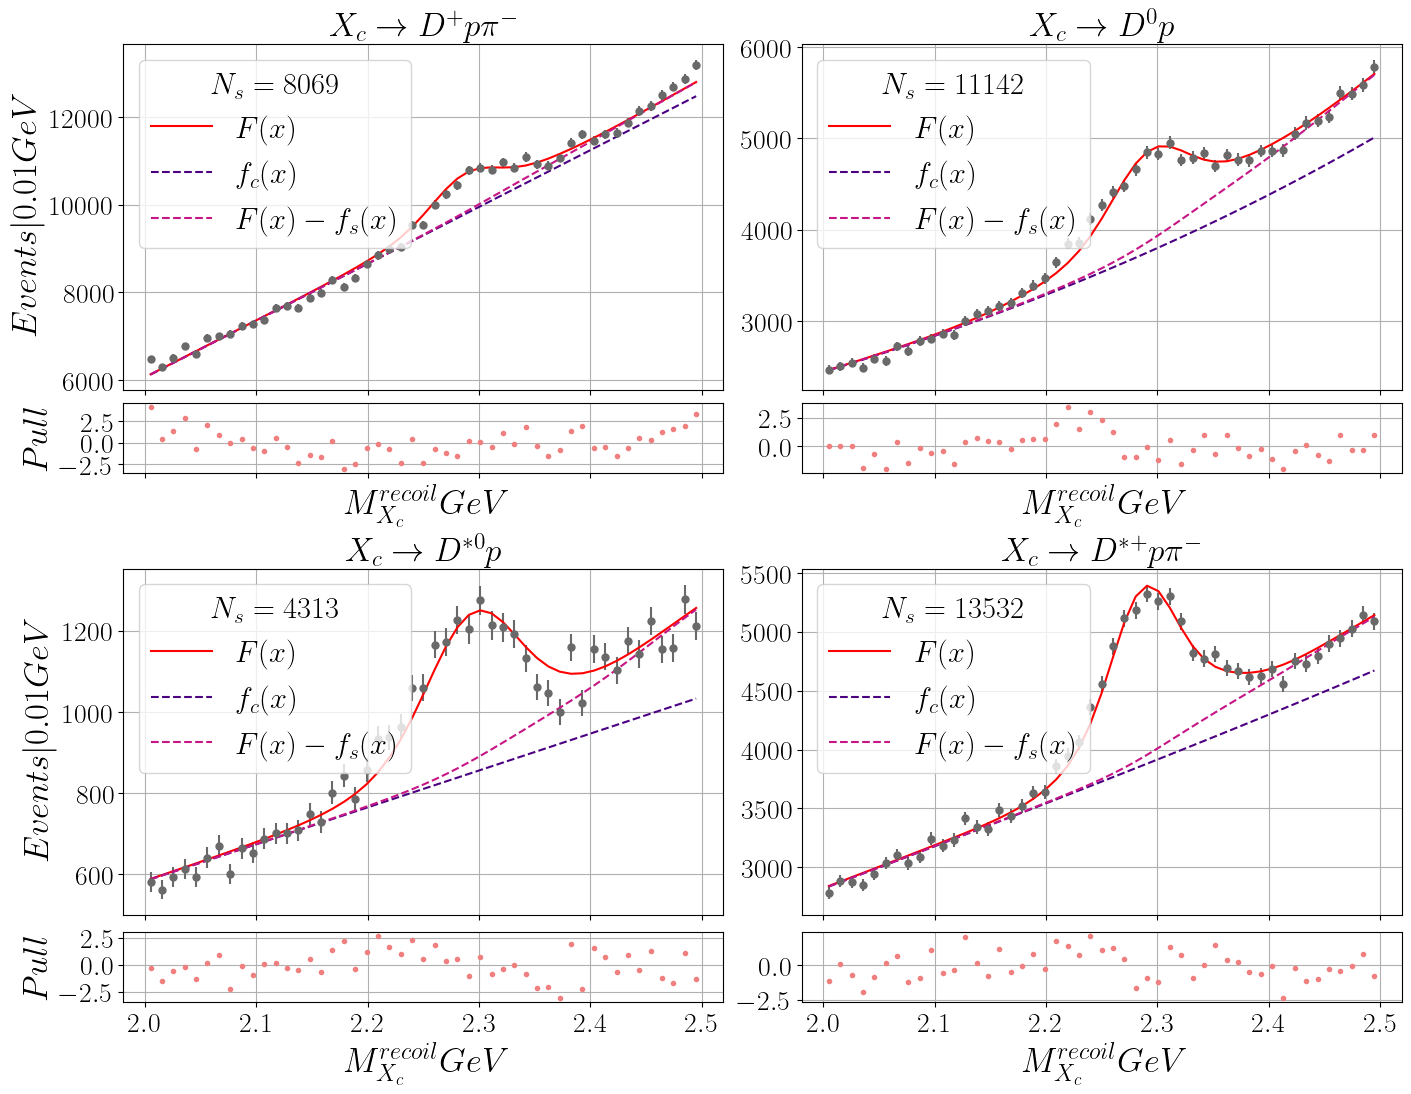

In [14]:
fig, axs = plt.subplots(4, 2, figsize=(14, 26*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]*2}, sharex=True)
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i)]
    N = dat.shape[0]; ax_main = axs[ind//2 * 2, ind%2]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = ax_main)
    args, pdf, norm = max_bin_lik(functions[ind], bin_centers, counts, initial_params_s[ind], wbin = wbin)
    initial_params_s[ind] = args
    ax_main.plot(bin_centers, pdf(bin_centers, norm, *args), label = "$F(x)$", color = 'red')
    ax_main.plot(bin_centers, __f_ns_nc(ind, bin_centers, *args)/np.sum(__f(ind, bin_centers, *args))*norm, '--', label = '$f_c(x)$', color = 'indigo')
    ax_main.plot(bin_centers, __f_ns(ind, bin_centers, *args)/np.sum(__f(ind, bin_centers, *args))*norm, '--', label = '$F(x) - f_s(x)$', color = 'mediumvioletred')

    N_s = int(np.sum(__f(ind, bin_centers, *args)/np.sum(__f(ind, bin_centers, *args))*norm) - np.sum(__f_ns(ind, bin_centers, *args)/np.sum(__f(ind, bin_centers, *args))*norm))
    expected = pdf(bin_centers, norm, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    
    ax_main.legend(title=f"$N_s = {N_s}$")
    ax_main.set_title(decay_mod_taging[ind])
    if ind%2 == 0:
        ax_main.set_ylabel(f'$Events | {wbin} GeV$')
    ax_main.grid()


    residuals = counts - pdf(bin_centers, norm, *args)
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$Pull$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
plt.show() 

AttributeError: 'DataFrame' object has no attribute 'IsSignalXc'

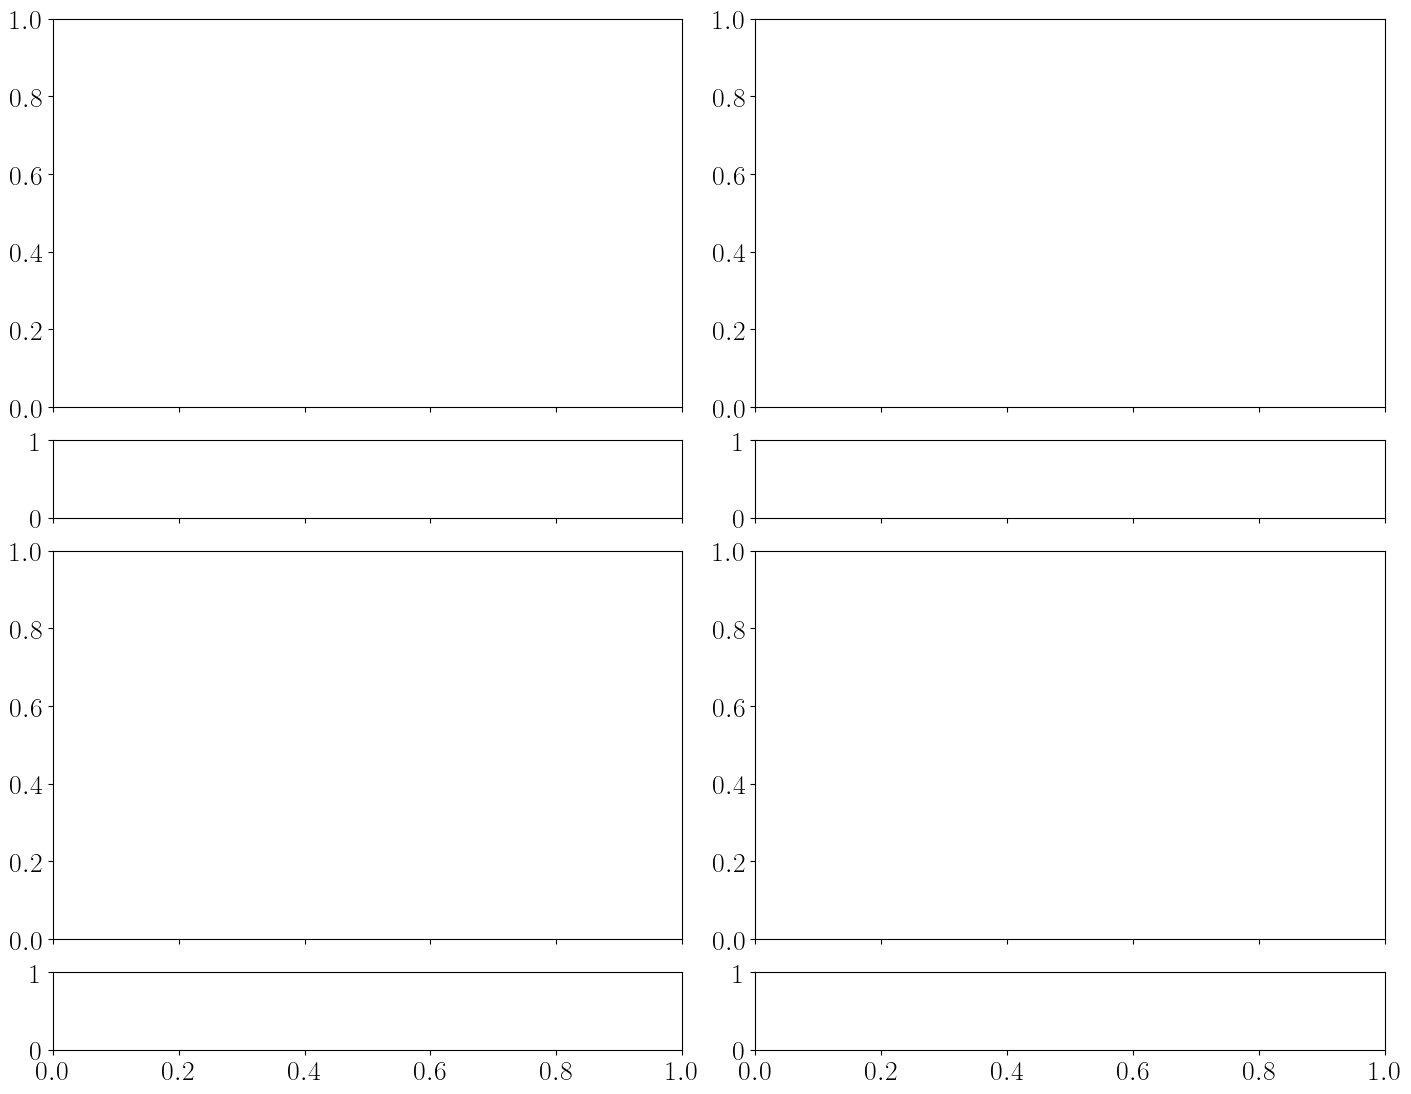

In [15]:
f_list = []
fig, axs = plt.subplots(4, 2, figsize=(14, 26*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]*2}, sharex=True)

params_dict = {}

save = True

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)<0.01) & ((inc.isPiFromLc == 0) | (inc.isPFromLc == 0))]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$hist$", axs=axs[ind//2 * 2, ind%2 ])      
    
    N = dat.shape[0]
    f_sig = fitting_functions_s[ind]
    args = initial_params_s[ind]

    ax_main = axs[ind//2 * 2, ind%2]
    initial_params_s[ind], pdf, norm = max_bin_lik(f_sig, bin_centers, counts, args, wbin = wbin)

    args =  [norm, *initial_params_s[ind]]; f_sig = pdf
    title = decay_mod_taging[i-1]

    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(bin_centers, f_sig(bin_centers, *args), label="$f_{sig}(x)$", color = 'red')

    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$Events | {wbin} GeV$')
    ax_main.grid()

    ax_main.legend(title=f"$\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$ \n $N = {norm:.0f}$\n $N_r = {np.sum(counts)}$")

    if save:
        params_dict[i] = {'initial_params': initial_params_s[ind], 'norm': norm}

    residuals = counts - f_sig(bin_centers, *args)
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$Pull$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
